# Détection d'émotions dans les tweets : TF-IDF vs BERT

**Projet NLP — AI 2026–2027** :  Asma Allaigui , Nourchene Boumaiza · ESSAI

**Dataset** : CrowdFlower *« Emotion in Text »*, 40 000 tweets annotés en 13 émotions
- Kaggle : https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text
- Source originale : https://data.world/crowdflower/sentiment-analysis-in-text

**Plan** : 1. Introduction · 2. État de l'art · 3. Données · 4. Préparation · 5. Méthodologie · 6. Implémentation · 7. Résultats · 8. Analyse des erreurs · 9. Limites et perspectives · 10. Conclusion · 11. Références · 12. Déclaration IA

> Exécution : Kaggle avec **GPU** et **Internet** activés (téléchargement de BERT).

## 1. Introduction et problématique

### 1.1 Contexte
L'analyse de sentiments classique se limite souvent à une polarité (positif / négatif / neutre). La **détection d'émotions** vise une granularité plus fine (joie, tristesse, colère, surprise…), utile pour l'analyse de retours clients, le suivi de l'opinion publique ou la modération de contenus. Sur Twitter, la tâche est particulièrement difficile :
- **textes très courts** (≤ 140 caractères à l'époque de la collecte), donc peu de contexte ;
- **langage bruité** : argot, abréviations (`u`, `im`, `2day`), fautes, élongations (`soooo`), émoticônes, mentions, URLs ;
- **ironie et implicite** : l'émotion n'est pas toujours portée par des mots explicites ;
- **subjectivité de l'annotation** : deux annotateurs peuvent légitimement attribuer des émotions différentes au même tweet.

### 1.2 Problématique
**un modèle pré-entraîné comme BERT, qui comprend le contexte, fait-il nettement mieux que des baselines classiques (TF-IDF + régression logistique ou SVM) sur des tweets courts et bruités ?**

### 1.3 Démarche
exploration des données → prétraitement justifié → baseline optimisée → BERT → comparaison sur le même jeu de test → analyse des erreurs.

## 2. État de l'art

- **Modèles des émotions.** Ekman [1] définit 6 émotions de base ; Russell [2] décrit les émotions selon deux axes, la *valence* (positif / négatif) et l'*activation* (intensité). Ce second modèle nous sert à regrouper les classes.
- **Approches classiques.** Une représentation TF-IDF combinée à un modèle linéaire (SVM, régression logistique) reste une baseline solide pour les textes courts [3].
- **Émotions sur Twitter.** La campagne SemEval-2018 *Affect in Tweets* [4] a servi de benchmark de référence pour cette tâche.
- **Transformers.** BERT [5] est pré-entraîné sur de grands corpus puis *fine-tuné* sur la tâche cible ; il représente chaque mot **selon son contexte**. Les benchmarks sur tweets (TweetEval [6]) montrent un net gain des Transformers sur les méthodes classiques.

## 3. Données
 - CrowdFlower *« Emotion in Text »*, 40 000 tweets annotés en 13 émotions
- Kaggle : https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text
- Source originale : https://data.world/crowdflower/sentiment-analysis-in-text
### 3.1 Chargement
Imports, configuration, puis lecture du fichier. La colonne `sentiment` est renommée `emotion`.

In [ ]:
import html
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_colwidth", 110)
RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/asmaallaigui/emotion-data/tweet_emotions.csv"
BLUE, ORANGE = "#2a78d6", "#eb6834"


def load_dataset(path):
    data = pd.read_csv(path).rename(columns=lambda c: c.strip().lower())
    return data.rename(columns={"sentiment": "emotion"}).assign(content=lambda d: d["content"].astype(str))


raw_df = load_dataset(DATA_PATH)
raw_df.head()

,tweet_id,emotion,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habit earlier and i started freakin at his part =[
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin on your call...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,"@dannycastillo We want to trade with someone who has Houston tickets, but no one will."


### 3.2 Qualité et distribution des classes
On vérifie les valeurs manquantes et les doublons, puis la répartition des 13 émotions.

,valeur
tweets,40000
valeurs manquantes,0
textes dupliqués,173
textes avec labels contradictoires,62


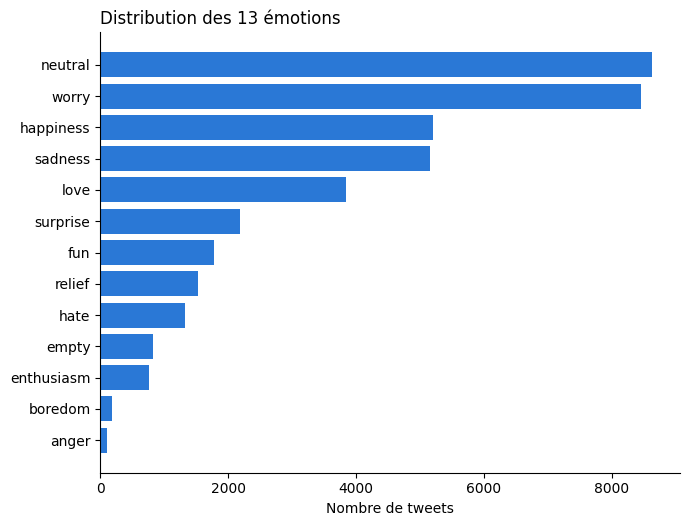

In [ ]:
def quality_report(data):
    return pd.Series({
        "tweets": len(data),
        "valeurs manquantes": int(data.isna().sum().sum()),
        "textes dupliqués": int(data.duplicated(subset="content").sum()),
        "textes avec labels contradictoires": int((data.groupby("content")["emotion"].nunique() > 1).sum()),
    }).to_frame("valeur")


def plot_distribution(labels, title):
    counts = labels.value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(7, 0.32 * len(counts) + 1.2))
    ax.barh(counts.index, counts.values, color=BLUE)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Nombre de tweets")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


display(quality_report(raw_df))
plot_distribution(raw_df["emotion"], "Distribution des 13 émotions")

**À retenir**
- Le dataset est **très déséquilibré** : `neutral` et `worry` ≈ 21 % chacune, `anger` seulement 0,27 % (ratio ≈ 78:1). L'accuracy est donc trompeuse, et on utilisera le **F1-macro**, qui donne le même poids à chaque classe.
- Certains textes identiques ont **des labels différents** : c'est une première preuve de bruit dans l'annotation.

## 4. Préparation des données

### 4.1 Doublons et regroupement des classes
- On supprime les doublons, ainsi que les textes aux labels contradictoires, pour éviter qu'un même tweet se retrouve dans le train **et** le test.
- Les 13 émotions sont regroupées en **6 macro-émotions** selon la valence et l'activation (Russell [2]). Des classes comme `anger` (110 tweets) ou `boredom` (179) sont trop petites pour être apprises seules.

| Macro-émotion | Émotions d'origine |
|---|---|
| neutral | neutral, empty |
| sadness | sadness, worry, boredom |
| joy | happiness, fun, enthusiasm, relief |
| love | love |
| anger | hate, anger |
| surprise | surprise |

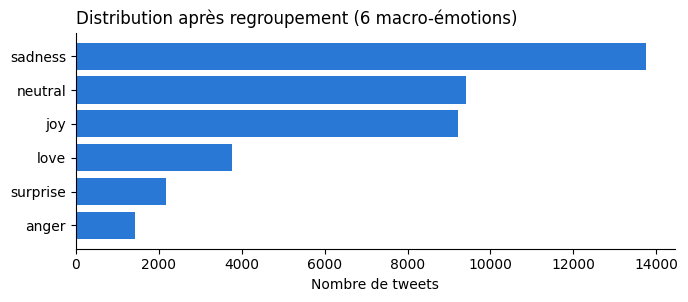

In [ ]:
EMOTION_GROUPS = {
    "neutral": "neutral", "empty": "neutral",
    "sadness": "sadness", "worry": "sadness", "boredom": "sadness",
    "happiness": "joy", "fun": "joy", "enthusiasm": "joy", "relief": "joy",
    "love": "love", "hate": "anger", "anger": "anger", "surprise": "surprise",
}
LABELS = ["sadness", "neutral", "joy", "love", "surprise", "anger"]


def prepare(data):
    n_labels = data.groupby("content")["emotion"].transform("nunique")
    clean = data[n_labels == 1].drop_duplicates(subset="content").reset_index(drop=True)
    return clean.assign(label=clean["emotion"].map(EMOTION_GROUPS))


df = prepare(raw_df)
plot_distribution(df["label"], "Distribution après regroupement (6 macro-émotions)")

Le déséquilibre passe de **78:1 à environ 10:1**. Il reste important, d'où l'utilisation de la **pondération des classes** dans les deux modèles.

### 4.2 Prétraitement du texte
Deux versions du texte sont construites : `text_tfidf` pour les baselines, `text_bert` pour BERT.

**Corrections apportées à mon premier prétraitement**
1. **Entités HTML décodées** (`html.unescape`) au lieu d'être supprimées : `&lt;3` devient `<3` (cœur), `&amp;` devient `&`.
2. **Émoticônes conservées sous forme de jetons** (`xxsmile`, `xxsad`, `xxheart`) : elles étaient auparavant effacées par le filtre `[^a-z\s']` alors qu'elles sont un marqueur émotionnel direct.
3. **URLs et mentions remplacées par `xxurl` / `xxuser`** : l'ancien remplacement par `<url>` perdait ses chevrons au nettoyage et devenait le mot `url`/`user`, confondu avec les vrais mots. Le préfixe `xx` évite toute collision.
4. **Élongations réduites** (`soooo` → `soo`) : on garde une trace de l'intensité sans multiplier le vocabulaire.
5. **Points d'exclamation et d'interrogation** conservés sous forme de jetons (`xxexcl`, `xxquest`), marqueurs d'intensité et de surprise.
6. **Contractions et argot Twitter** : `can't` → `cannot`, `im` → `i am`, `u` → `you`, `2day` → `today`. La règle `'s → is` a été supprimée, car elle transformait aussi les possessifs (`john's`).
7. **Stopwords** : les négations (`not`, `never`, `no`…) **et** les intensifieurs (`very`, `really`, `so`, `too`…) sont conservés, car ils modulent l'émotion (*not happy*, *so sad*).
8. **Lemmatisation par lots** (`nlp.pipe`) : environ 10× plus rapide que `apply(nlp)` ligne par ligne.

**Et pour BERT ?** Presque rien : décodage HTML, URLs → `http`, mentions → `@user`. BERT a été pré-entraîné sur du texte naturel ; lemmatiser ou retirer des mots lui enlèverait du contexte (négations, ponctuation, ordre des mots).

In [ ]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
EMOTICONS = {
    "xxheart": re.compile(r"<3+"),
    "xxsmile": re.compile(r"(?<!\w)(?:[:;=]-?[)\]dp]|\^\^)(?!\w)"),
    "xxsad": re.compile(r"(?<!\w)[:;=]'?-?[(\[/](?!\w)"),
}
CONTRACTIONS = {
    r"\bwon't\b": "will not", r"\bcan't\b": "cannot", r"n't\b": " not", r"'m\b": " am",
    r"'re\b": " are", r"'ll\b": " will", r"'ve\b": " have", r"'d\b": " would", r"'s\b": "",
}
SLANG = {
    "im": "i am", "dont": "do not", "cant": "cannot", "didnt": "did not", "isnt": "is not",
    "u": "you", "ur": "your", "r": "are", "gonna": "going to", "wanna": "want to",
    "b4": "before", "2day": "today", "2morrow": "tomorrow", "2nite": "tonight", "gr8": "great",
}
KEEP_WORDS = {"no", "not", "never", "none", "nothing", "nobody", "cannot",
              "very", "really", "so", "too", "much", "more", "most", "only", "again"}
STOPWORDS = STOP_WORDS - KEEP_WORDS


def normalize_tweet(text):
    text = html.unescape(text).replace("’", "'").lower()
    text = URL_RE.sub(" xxurl ", text)
    text = MENTION_RE.sub(" xxuser ", text)
    for token, pattern in EMOTICONS.items():
        text = pattern.sub(f" {token} ", text)
    text = re.sub(r"!+", " xxexcl ", text)
    text = re.sub(r"\?+", " xxquest ", text)
    text = re.sub(r"(\w)\1{2,}", r"\1\1", text)
    for pattern, replacement in CONTRACTIONS.items():
        text = re.sub(pattern, replacement, text)
    tokens = " ".join(SLANG.get(tok, tok) for tok in re.sub(r"[^a-z0-9\s]", " ", text).split()).split()
    return " ".join(tok for tok in tokens if tok.isalpha())


def lemmatize_filter(texts):
    return [
        " ".join(tok.text if tok.text.startswith("xx") else tok.lemma_.lower()
                 for tok in doc if tok.text.startswith("xx") or tok.text not in STOPWORDS)
        for doc in nlp.pipe(texts, batch_size=1000)
    ]


def clean_for_bert(text):
    text = URL_RE.sub("http", html.unescape(text))
    return MENTION_RE.sub("@user", text).strip()

Application au corpus. Les tweets devenus vides après nettoyage (ex. un tweet ne contenant qu'un nombre) sont retirés, pour que tous les modèles soient évalués sur les mêmes tweets.

In [ ]:
df["text_tfidf"] = lemmatize_filter(df["content"].map(normalize_tweet))
df["text_bert"] = df["content"].map(clean_for_bert)
df = df[df["text_tfidf"].str.len() > 0].reset_index(drop=True)
df[["content", "text_tfidf", "text_bert"]].sample(6, random_state=RANDOM_STATE)

,content,text_tfidf,text_bert
4528,@TheRealScarab and this is better 4 me than a snickers bar or hersheys w/almonds.... which i use to b addi...,xxuser well snicker bar hershey w almond use b addict miss lol,@user and this is better 4 me than a snickers bar or hersheys w/almonds.... which i use to b addicted to b...
27383,This is going to be a great and productive week - I can just feel it!!! POSITIVE THINKING is the key,go great productive week feel xxexcl positive thinking key,This is going to be a great and productive week - I can just feel it!!! POSITIVE THINKING is the key
33116,@artistiquemeg wooohooo! I'm fourth row back,xxuser woohoo xxexcl fourth row,@user wooohooo! I'm fourth row back
8420,"@stacywillert yeah that was me yesterday after i found out the house i want is sold, my bank effed me over...",xxuser yeah yesterday find house want sell bank eff car accident,"@user yeah that was me yesterday after i found out the house i want is sold, my bank effed me over and the..."
15356,"@karenneves few hotels in UK have free wifi, they are mega expensive here and usually only hard wired. Lo...",xxuser hotel uk free wifi mega expensive usually only hard wire love hotel wifi states xxexcl,"@user few hotels in UK have free wifi, they are mega expensive here and usually only hard wired. Loved us..."
33884,"I just got a call from my chimp buddies, want to join the party. Loads to prepare now. Wow this is great. ...",get chimp buddy want join party load prepare wow great cup tea think erm,"I just got a call from my chimp buddies, want to join the party. Loads to prepare now. Wow this is great. ..."



### 4.3 Découpage train / test
80 % train / 20 % test, **stratifié** pour garder les mêmes proportions de classes. Le test n'est utilisé **qu'à la fin**, pour comparer les deux modèles.

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE)
y_train, y_test = train_df["label"].to_numpy(), test_df["label"].to_numpy()
pd.Series({"train": len(train_df), "test": len(test_df)}).to_frame("tweets")

,tweets
train,31800
test,7950


## 5. Méthodologie

| | Baseline | Modèle avancé |
|---|---|---|
| **Modèle** | TF-IDF (unigrammes + bigrammes) + **régression logistique** et **SVM linéaire** | BERT-base uncased, fine-tuné |
| **Idée** | un tweet = un sac de mots pondérés ; la régression logistique estime des probabilités, le SVM cherche la frontière de plus grande marge | chaque mot est représenté selon son contexte |
| **Réglage** | *Grid Search* sur `C` et `class_weight`, validation croisée 5 plis ; la meilleure des deux (selon la CV) sert de référence | lr = 2e-5, 3 epochs, meilleur epoch choisi sur une validation (10 % du train) |
| **Déséquilibre** | `class_weight="balanced"` testé dans le Grid Search | loss pondérée par classe |

**Métriques** : **F1-macro** (principale), accuracy, précision et rappel macro, F1 par classe et matrice de confusion.

## 6. Implémentation

### 6.1 Baselines : TF-IDF + régression logistique / SVM linéaire
Le TF-IDF est placé **dans le `Pipeline`** : pendant la validation croisée, il est réappris sur chaque pli, sans jamais voir les données de validation. `GridSearchCV` teste chaque combinaison et garde celle qui a le meilleur F1-macro moyen.

In [ ]:
from sklearn.svm import LinearSVC

BASELINES = {
    "TF-IDF + LogReg": (LogisticRegression(max_iter=2000), {"clf__C": [0.3, 1, 3], "clf__class_weight": [None, "balanced"]}),
    "TF-IDF + SVM": (LinearSVC(max_iter=5000), {"clf__C": [0.1, 0.3, 1], "clf__class_weight": [None, "balanced"]}),
}


def train_baseline(classifier, grid, texts, labels):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("clf", classifier),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"f1_macro": "f1_macro", "accuracy": "accuracy"}
    return GridSearchCV(pipeline, grid, scoring=scoring, refit="f1_macro", cv=cv, n_jobs=-1).fit(texts, labels)


def grid_table(search):
    res = search.cv_results_
    return pd.DataFrame({
        "C": res["param_clf__C"],
        "class_weight": pd.Series(res["param_clf__class_weight"]).fillna("None"),
        "F1-macro CV": res["mean_test_f1_macro"],
        "écart-type": res["std_test_f1_macro"],
        "accuracy CV": res["mean_test_accuracy"],
    }).sort_values("F1-macro CV", ascending=False).round(3)


searches = {name: train_baseline(clf, grid, train_df["text_tfidf"], y_train) for name, (clf, grid) in BASELINES.items()}
pd.concat({name: grid_table(search) for name, search in searches.items()})

C class_weight  F1-macro CV  écart-type  accuracy CV
TF-IDF + LogReg 1  0.3     balanced        0.381       0.005        0.433
                3  1.0     balanced        0.379       0.004        0.438
                5  3.0     balanced        0.368       0.005        0.436
                4  3.0         None        0.347       0.007        0.479
                2  1.0         None        0.343       0.005        0.495
                0  0.3         None        0.321       0.002        0.497
TF-IDF + SVM    1  0.1     balanced        0.390       0.005        0.468
                3  0.3     balanced        0.370       0.006        0.450
                5  1.0     balanced        0.346       0.005        0.429
                2  0.3         None        0.345       0.007        0.484
                0  0.1         None        0.341       0.005        0.499
                4  1.0         None        0.334       0.010        0.453

On retient comme référence la baseline qui a le meilleur F1-macro **en validation croisée** (et non sur le test, pour ne pas biaiser le choix).

In [ ]:
BEST_BASELINE = max(searches, key=lambda name: searches[name].best_score_)
pd.DataFrame({
    name: {"meilleurs paramètres": search.best_params_, "F1-macro CV": round(search.best_score_, 3)}
    for name, search in searches.items()
}).T.assign(retenue=lambda d: d.index == BEST_BASELINE)

,meilleurs paramètres,F1-macro CV,retenue
TF-IDF + LogReg,"{'clf__C': 0.3, 'clf__class_weight': 'balanced'}",0.381,False
TF-IDF + SVM,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.39,True


Le tableau montre l'effet de chaque hyperparamètre. `class_weight="balanced"` aide normalement le F1-macro, car il force le modèle à ne pas ignorer les classes rares, même si l'accuracy peut baisser légèrement.

### 6.2 Modèle avancé : fine-tuning de BERT
Étapes :
1. **Tokenisation** : le tokenizer de BERT découpe le tweet en sous-mots (64 tokens maximum, ce qui suffit pour un tweet).
2. **Modèle** : BERT pré-entraîné + une couche de classification à 6 sorties.
3. **Entraînement** avec le `Trainer` de Hugging Face : loss pondérée par classe, évaluation à chaque epoch, et conservation du meilleur epoch selon le F1-macro de validation.

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

MODEL_NAME = "bert-base-uncased"
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=64, padding="max_length")
        self.labels = [LABEL2ID[label] for label in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {key: torch.tensor(values[i]) for key, values in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item


bert_train, bert_val = train_test_split(train_df, test_size=0.1, stratify=train_df["label"], random_state=RANDOM_STATE)
train_set = TweetDataset(bert_train["text_bert"], bert_train["label"])
val_set = TweetDataset(bert_val["text_bert"], bert_val["label"])
test_set = TweetDataset(test_df["text_bert"], test_df["label"])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

La loss est pondérée par l'inverse de la fréquence de chaque classe : une erreur sur `anger` coûte environ 10 fois plus cher qu'une erreur sur `sadness`.

In [ ]:
counts = bert_train["label"].value_counts().reindex(LABELS).to_numpy()
CLASS_WEIGHTS = torch.tensor(len(bert_train) / (len(LABELS) * counts), dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(outputs.logits.device))
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return {"f1_macro": f1_score(labels, logits.argmax(axis=1), average="macro")}


args = TrainingArguments(
    output_dir="bert_emotions", num_train_epochs=3, learning_rate=2e-5,
    per_device_train_batch_size=32, per_device_eval_batch_size=64, weight_decay=0.01, warmup_steps=int(0.1 * 3 * len(train_set) / 32),
    eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(), report_to="none", seed=RANDOM_STATE,
)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LABELS))
trainer = WeightedTrainer(model=model, args=args, train_dataset=train_set, eval_dataset=val_set, compute_metrics=compute_metrics)
trainer.train()
pd.DataFrame(trainer.state.log_history).dropna(subset=["eval_f1_macro"])[["epoch", "eval_loss", "eval_f1_macro"]].round(4)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,1.430774,0.372041
2,1.566538,1.388216,0.393435
3,1.292185,1.436362,0.402025


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,epoch,eval_loss,eval_f1_macro
0,1.0,1.4308,0.3720
2,2.0,1.3882,0.3934
4,3.0,1.4364,0.4020


Le tableau donne, à chaque epoch, la loss et le F1-macro sur la validation. Si la loss de validation remonte, le modèle commence à **surapprendre** : le `Trainer` garde alors automatiquement le meilleur epoch.

## 7. Résultats

### 7.1 Comparaison sur le jeu de test
Les deux modèles sont évalués sur **exactement les mêmes tweets de test**, jamais vus pendant l'entraînement ni pendant les réglages.

In [ ]:
def evaluate(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}


predictions = {name: search.predict(test_df["text_tfidf"]) for name, search in searches.items()}
predictions["BERT"] = np.array(LABELS)[trainer.predict(test_set).predictions.argmax(axis=1)]
pd.DataFrame({name: evaluate(y_test, pred) for name, pred in predictions.items()}).T.round(3)

,accuracy,precision_macro,recall_macro,f1_macro
TF-IDF + LogReg,0.436,0.380,0.425,0.384
TF-IDF + SVM,0.470,0.385,0.406,0.393
BERT,0.470,0.410,0.470,0.417


### 7.2 F1 par émotion

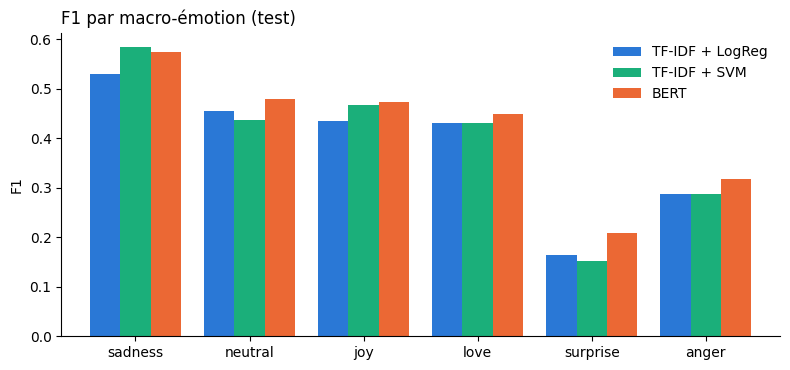

,TF-IDF + LogReg,TF-IDF + SVM,BERT
sadness,0.530,0.584,0.573
neutral,0.455,0.437,0.480
joy,0.436,0.467,0.473
love,0.431,0.431,0.450
surprise,0.165,0.152,0.208
anger,0.288,0.286,0.317


In [ ]:
def plot_f1_per_class(y_true, predictions):
    scores = pd.DataFrame({name: f1_score(y_true, pred, labels=LABELS, average=None) for name, pred in predictions.items()}, index=LABELS)
    ax = scores.plot(kind="bar", figsize=(8, 3.8), color=[BLUE, "#1baf7a", ORANGE], width=0.8, rot=0)
    ax.set_ylabel("F1")
    ax.set_title("F1 par macro-émotion (test)", loc="left")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    return scores.round(3)


plot_f1_per_class(y_test, predictions)

**Lecture des résultats**
- BERT obtient le meilleur F1-macro (≈ 0,417), contre ≈ 0,393 pour le SVM et ≈ 0,384 pour la régression logistique, soit +2,4 points par rapport à la meilleure baseline. Le gain est modeste, mais BERT est meilleur ou quasi égal sur toutes les classes.
- Le gain est le plus fort sur les classes difficiles : surprise (0,208 contre 0,152 pour le SVM, soit +5,6 points) et anger (0,317 contre 0,286, soit +3,1 points). BERT exploite le contexte là où les mots seuls sont peu discriminants.
- Le SVM reste légèrement meilleur sur sadness (0,584 contre 0,573). C'est la classe la plus fréquente, avec un vocabulaire explicite (sad, miss, tired), qu'un modèle sac-de-mots capture déjà très bien.
- Entre les deux baselines, le SVM dépasse la régression logistique sur sadness et joy, mais fait un peu moins bien sur neutral. Leurs performances globales sont proches.
- surprise et anger restent les classes les plus difficiles pour tous les modèles (F1 < 0,32), à cause de leur faible effectif et de leur vocabulaire peu spécifique.

## 8. Analyse des erreurs

### 8.1 Matrices de confusion
Pour la meilleure baseline et BERT, normalisées par ligne : la diagonale donne le **rappel** de chaque classe, et les autres cases montrent **avec quelle classe** le modèle se trompe.

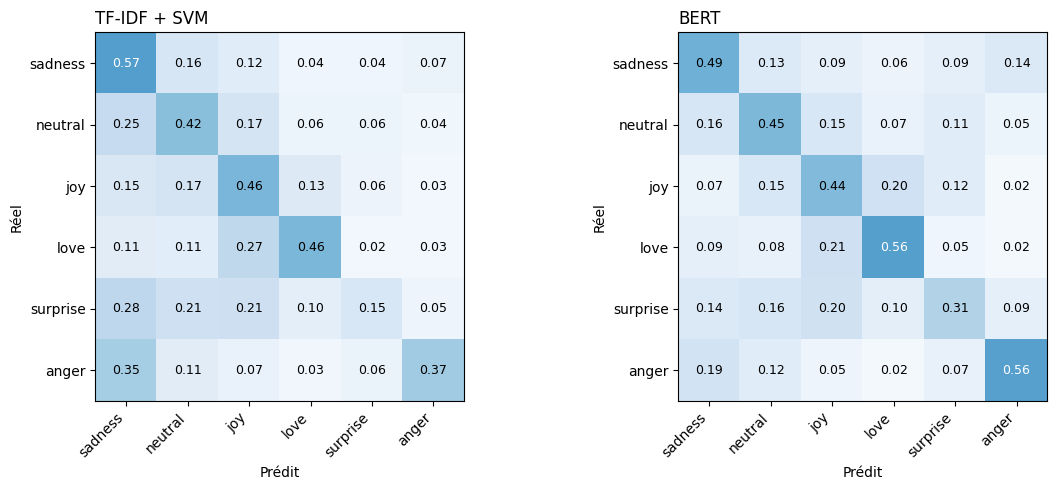

In [ ]:
def plot_confusions(y_true, predictions):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (name, y_pred) in zip(axes, predictions.items()):
        cm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")
        ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
        ax.set(xticks=range(6), yticks=range(6), xticklabels=LABELS, yticklabels=LABELS, xlabel="Prédit", ylabel="Réel")
        ax.set_title(name, loc="left")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        for i, j in np.ndindex(cm.shape):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=9, color="white" if cm[i, j] > 0.5 else "black")
    plt.tight_layout()
    plt.show()


plot_confusions(y_test, {BEST_BASELINE: predictions[BEST_BASELINE], "BERT": predictions["BERT"]})

### 8.2 Exemples d'erreurs de BERT
Quelques tweets mal classés : ils permettent de distinguer les vraies faiblesses du modèle des labels discutables.

In [ ]:
errors = test_df.assign(prediction=predictions["BERT"])
errors[errors["label"] != errors["prediction"]][["content", "emotion", "label", "prediction"]].sample(10, random_state=RANDOM_STATE)

,content,emotion,label,prediction
26272,Woke up after about 6 hours of sleep. Feeling better now,neutral,neutral,surprise
14923,Farewell dinner with my kimmy. Last time i'll see her in a while,love,love,joy
1832,is tired of being tired,empty,neutral,anger
27090,"@Joy_B I don't know but they aren't worth it, only 6 people actually showed up lol",fun,joy,surprise
26413,Morning Tweethearts! Now home after traveling 302 mi.thru 2 states &amp; 2 faires in 3 days. So inspired! ...,surprise,surprise,joy
33681,Wishing all the Mama's out there a very Organic Happy Mother's Day,neutral,neutral,love
30378,"@iampritty sweetie pie, buttercup, married ppl share hehehehehe.....this includes ur shoe collection I am...",worry,sadness,love
3223,waiting for PRINCES PROTECTION PROGRAM online in English version so long,enthusiasm,joy,neutral
9389,@BusyElleBee That ur anti is what I understood from the message. Sorry left off ur don't vote BNP msg at e...,sadness,sadness,anger
32,I missed the bl***y bus!!!!!!!!,neutral,neutral,sadness


### 8.3 Interprétation
1. BERT reconnaît mieux les classes rares : son rappel passe de 0,37 à 0,56 sur anger et de 0,15 à 0,31 sur surprise. En contrepartie, le rappel de sadness baisse (0,57 → 0,49), car une partie de ces tweets est envoyée vers ces classes. C'est l'effet attendu de la loss pondérée.
2. anger ↔ sadness : ces deux émotions négatives partagent du vocabulaire. Avec BERT, la confusion baisse (35 % → 19 %), mais elle persiste.
3. joy ↔ love : environ 20 % de confusion entre ces deux émotions positives, dont la frontière est subjective, même pour un humain.
4. surprise n'a pas de vocabulaire propre : ses erreurs se dispersent sur toutes les classes, car une surprise peut être positive ou négative.
5. Beaucoup d'erreurs viennent de labels discutables : « I missed the bl***y bus!!! » est étiqueté neutral, alors que BERT prédit sadness, ce qui est plus logique. Une partie de l'erreur est donc irréductible avec ces données.

## 9. Analyse critique, limites et perspectives

**Limites**
- **Annotations bruitées** : une seule étiquette par tweet, attribuée par des annotateurs non experts ; cela plafonne les scores de tous les modèles.
- **Regroupement discutable** : `worry` est plutôt de la peur que de la tristesse, mais le dataset n'a pas de classe « peur ».
- **Une seule exécution de BERT** : le résultat peut varier de 1 à 2 points selon la graine aléatoire.
- **Données anciennes (2009), en anglais seulement** : la généralisation à des tweets récents n'est pas garantie.

**Perspectives**
- Utiliser un modèle pré-entraîné **sur des tweets** (Twitter-RoBERTa, BERTweet).
- Répéter l'entraînement avec plusieurs graines et donner la moyenne.
- Passer à une classification **multi-label**, car un tweet peut exprimer plusieurs émotions.

## 10. Conclusion

- Les baselines TF-IDF + régression logistique / SVM bien réglées atteignent un F1-macro d'environ 0,38–0,39.
- BERT fait mieux (≈ 0,417, soit +2,4 points), surtout sur les classes rares (surprise, anger), grâce au contexte.
- Le gain reste modeste : la qualité des annotations est la principale limite de ce dataset

## 11. Références

1. Ekman, P. (1992). An argument for basic emotions. *Cognition & Emotion*, 6(3–4).
2. Russell, J. A. (1980). A circumplex model of affect. *Journal of Personality and Social Psychology*, 39(6).
3. Wang, S., & Manning, C. D. (2012). Baselines and bigrams: simple, good sentiment and topic classification. *ACL 2012.*
4. Mohammad, S. M., et al. (2018). SemEval-2018 Task 1: Affect in Tweets. *SemEval-2018.*
5. Devlin, J., et al. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL 2019.*
6. Barbieri, F., et al. (2020). TweetEval: Unified benchmark and comparative evaluation for tweet classification. *Findings of EMNLP 2020.*

**Dataset** : CrowdFlower, *Sentiment Analysis: Emotion in Text* — https://data.world/crowdflower/sentiment-analysis-in-text · Kaggle : https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text

## 12. Déclaration d'utilisation d'outils d'IA générative

Nous avons utilisé un assistant d'IA générative (**Claude, Anthropic**) comme outil d'aide tout au long du projet : pour organiser le notebook selon la structure demandée, relire et améliorer notre prétraitement, et nous appuyer dans l'écriture du code (Grid Search, fine-tuning de BERT). Les choix méthodologiques (regroupement des classes, métriques, modèles comparés) ont été discutés et validés par nous. Nous avons exécuté, vérifié et compris l'ensemble du code, et l'interprétation des résultats repose sur nos propres exécutions.

> 